# **Aula 08** - Problemas de agrupamento - Parte 2

# **Exercício 1**. Agrupamento via algoritmo *DBSCAN* no *dataset Iris*

## **1)** Importação de bibliotecas e classes

In [1]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Bibliotecas específicas de Machine Learning
from sklearn.preprocessing import StandardScaler    # Padronização de atributos

## **2)** Leitura de dados e exploração inicial

In [3]:
# Leitura do arquivo de dados e exibição do DataFrame
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados!
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/A05EXEMPLO1_iris.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


### **2.1)** Gráficos

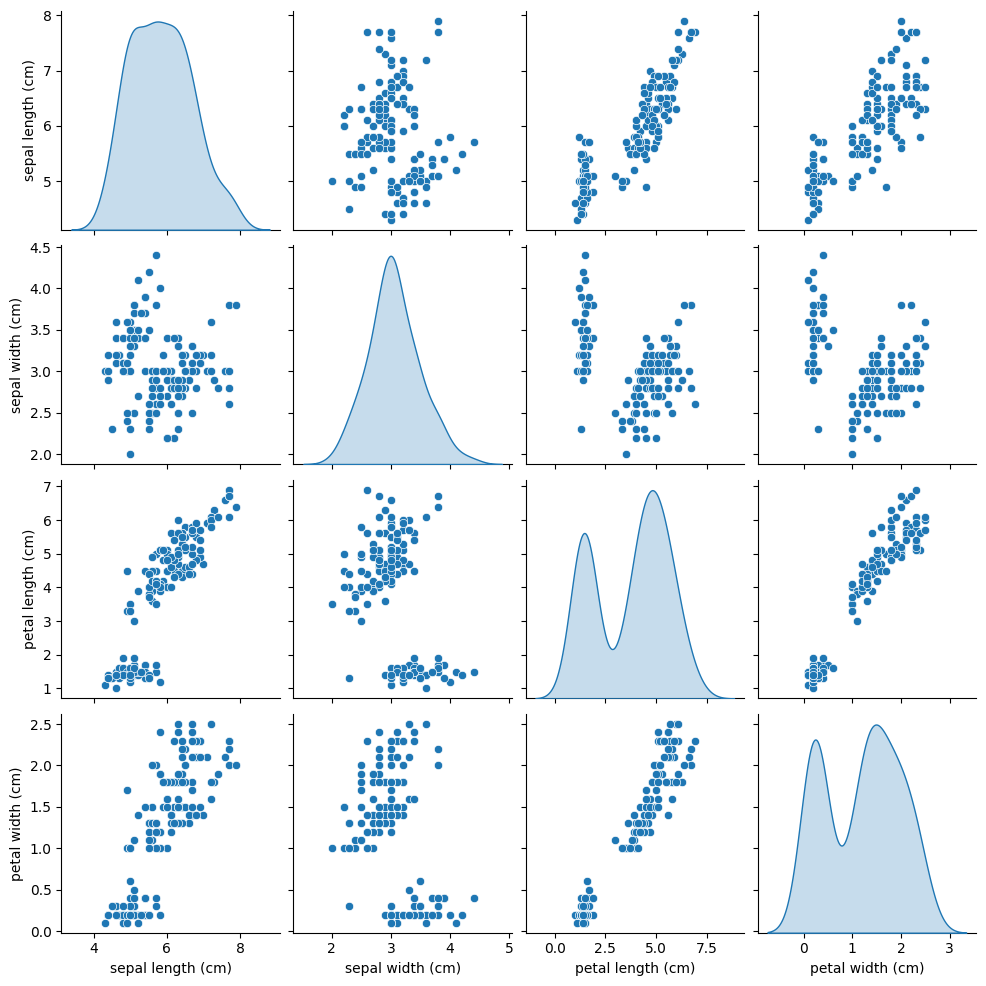

In [4]:
# Matriz de diagramas de dispersão (ignorando a rotulação)
sns.pairplot(data = df.drop(columns = ['target', 'species']), diag_kind = 'kde')
plt.show()

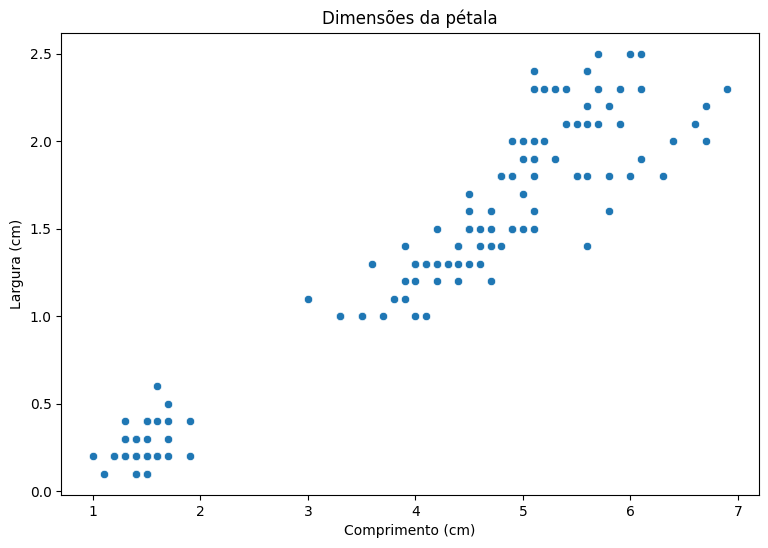

In [5]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)')
plt.show()

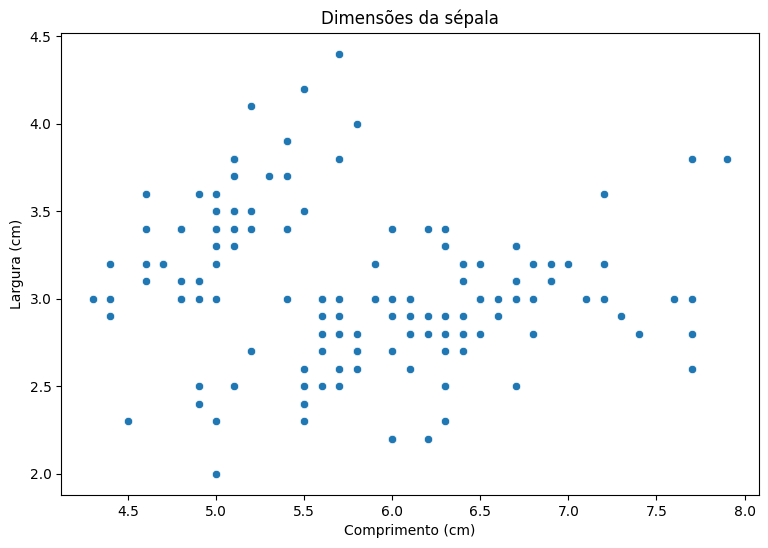

In [6]:
# Diagrama de dispersão entre comprimento e largura da sépala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)')
plt.show()

## **3)** Seleção e pré-processamento de variáveis

In [7]:
# Recordando os nomes das colunas do DataFrame
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [8]:
# Atributos: 4 dimensões das flores
X = df.drop(columns = ['target','species'])

In [9]:
# Pré-processamento ÚNICO: padronização dos atributos do CONJUNTO COMPLETO DE DADOS
escalonador = StandardScaler()      # Cria instância de objeto "escalonador"
escalonador.fit(X)                  # Calcula a média e a variância dos atributos
X_Padr = escalonador.transform(X)   # Padroniza os dados

## **4)** Agrupamento via algoritmo *DBSCAN*

### **4.1)** Treinamento do *clusterizador*

In [10]:
# Importação da biblioteca necessária para o uso do
# clusterizador baseado em densidade - algoritmo DBSCAN
from sklearn.cluster import DBSCAN

In [11]:
# PRIMEIRA TENTATIVA:
# Uso do algoritmo DBSCAN com os valores padrão
# dos hiperparâmetros: eps = 0.5; min_samples = 5
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = 0.5, min_samples = 5)
clt_DB.fit(X_Padr)

DBSCAN()

### **4.2**) Resultados do agrupamento

In [12]:
# Centros de clusters = pontos centrais
print("Foram identificados",len(clt_DB.core_sample_indices_),"pontos de centro.")
print("Índices:")
print(clt_DB.core_sample_indices_)

Foram identificados 93 pontos de centro.
Índices:
[  0   1   2   3   4   5   6   7   9  10  11  12  17  19  20  21  23  24
  25  26  27  28  29  30  31  34  35  36  37  38  39  40  42  43  44  45
  46  47  48  49  52  54  55  58  61  63  64  65  66  67  69  71  73  74
  75  77  78  79  80  81  82  83  86  88  89  90  91  92  94  95  96  97
  99 101 103 104 110 111 112 116 120 123 126 133 137 138 139 140 141 142
 143 145 147]


In [13]:
print("Rótulos dos elementos:")
print(clt_DB.labels_)

Rótulos dos elementos:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


In [14]:
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

Rótulos atribuídos: [-1  0  1]
34 elementos foram identificados como ruído.


In [15]:
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Total de elementos por cluster:
 1    71
 0    45
-1    34
Name: count, dtype: int64


### **4.3)** Gráficos

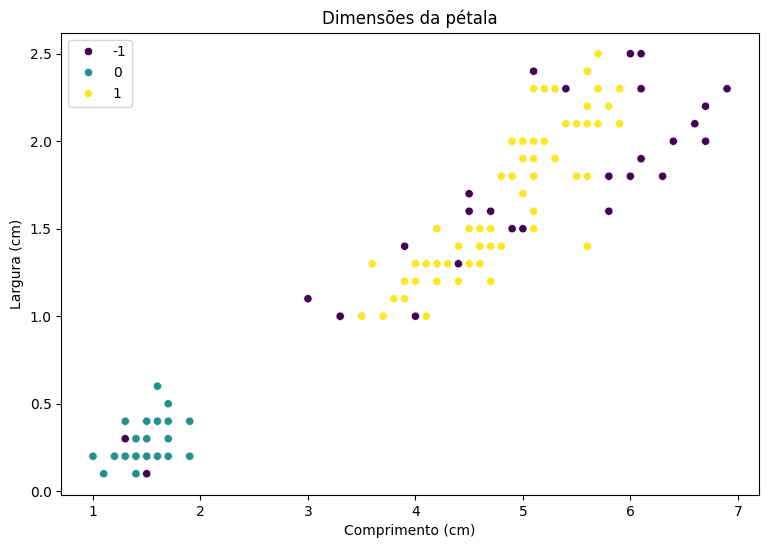

In [ ]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

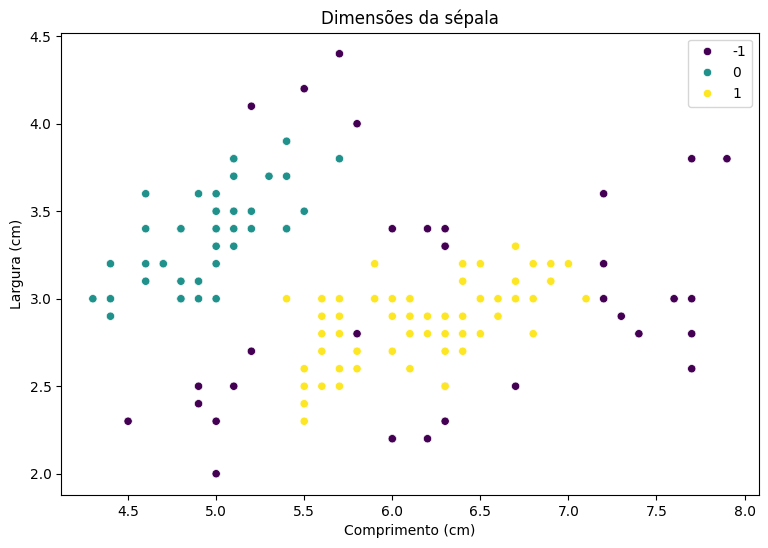

In [ ]:
# Diagrama de dispersão entre comprimento e largura da sépala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

## **5)** Dimensionamento dos hiperparâmetros

### **5.1)** Análise visual do raio de alcance

In [16]:
# Número mínimo de vizinhos (min_samples) = 2*total de atributos
k = 2*X_Padr.shape[1]
k

8

In [17]:
# Raio de alcance (eps)
# 1) Determinação da matriz de k menores distâncias
from sklearn.neighbors import NearestNeighbors

mdi = NearestNeighbors(n_neighbors = k+1).fit(X_Padr)   # Cria e treina instância
dist, ind = mdi.kneighbors(X_Padr)   # Calcula distâncias e índices
dist    # Exibe a matriz de distâncias. Neste caso, shape = (150,9)

array([[0.        , 0.13163218, 0.13383627, ..., 0.26013882, 0.2662756 ,
        0.35922722],
       [0.        , 0.16614339, 0.17890971, ..., 0.28389113, 0.43399991,
        0.48945463],
       [0.        , 0.13383627, 0.17051228, ..., 0.36350361, 0.36792033,
        0.37678398],
       ...,
       [0.        , 0.31365995, 0.40749818, ..., 0.46388867, 0.4770659 ,
        0.48240354],
       [0.        , 0.21196853, 0.50326741, ..., 0.72740278, 0.90623619,
        0.93498946],
       [0.        , 0.20917957, 0.26767253, ..., 0.61087766, 0.63590559,
        0.64553966]])

In [18]:
ind   # Exibe a matriz de índices

array([[  0,  17,  27, ...,  28,   7,  37],
       [  1,  25,  12, ...,  30,   3,  35],
       [  2,  47,  29, ...,  42,  35,   9],
       ...,
       [147, 116, 137, ..., 110,  77, 103],
       [148, 136, 100, ..., 110, 143, 140],
       [149, 138, 127, ..., 126,  66,  91]])

In [19]:
# 2) Ordenação das distâncias dos k-ésimos vizinhos mais próximos
dist = np.sort(dist,axis = 0)   # axis = 0: ordenação em cada COLUNA
k_dist = dist[:,k]    # Seleciona todas as linhas, última coluna

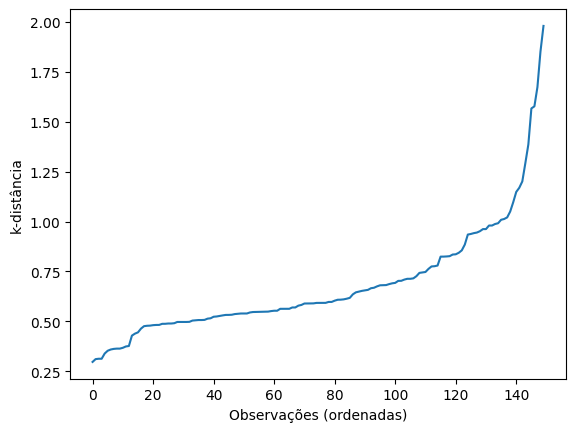

In [20]:
# 3) Traça a curva (gráfico de linha) da função k-distâncias (ordenadas)
plt.plot(k_dist)
plt.xlabel("Observações (ordenadas)")
plt.ylabel("k-distância")
plt.show()

In [21]:
# Definição do raio de alcance "ideal" (análise gráfica)
raio = 1

In [22]:
# SEGUNDA TENTATIVA:
# Uso do algoritmo DBSCAN com hiperparâmetros dimensionados
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = raio, min_samples = k)
clt_DB.fit(X_Padr)

DBSCAN(eps=1, min_samples=8)

In [23]:
# Exibição dos resultados do NOVO agrupamento
# Total de cluters e outliers
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

print("")   # "Imprime" uma linha em branco
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Rótulos atribuídos: [-1  0  1]
3 elementos foram identificados como ruído.

Total de elementos por cluster:
 1    98
 0    49
-1     3
Name: count, dtype: int64


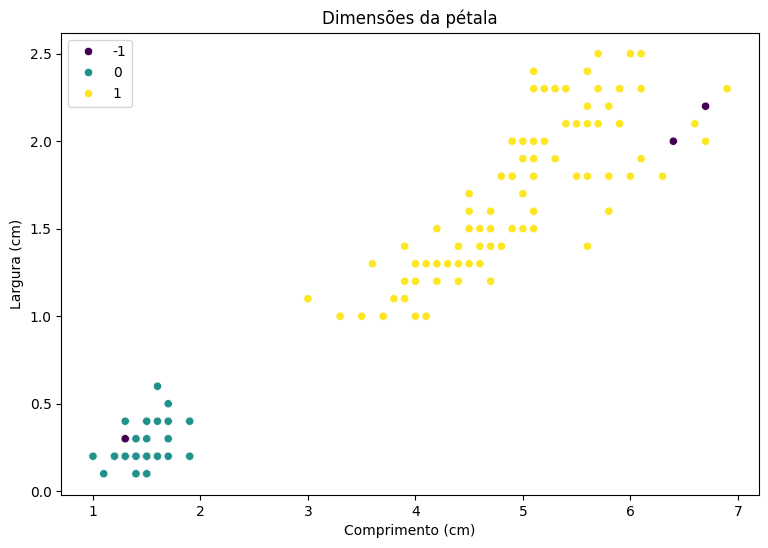

In [24]:
# Representações gráficas da SEGUNDA TENTATIVA de agrupamento via DBSCAN
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

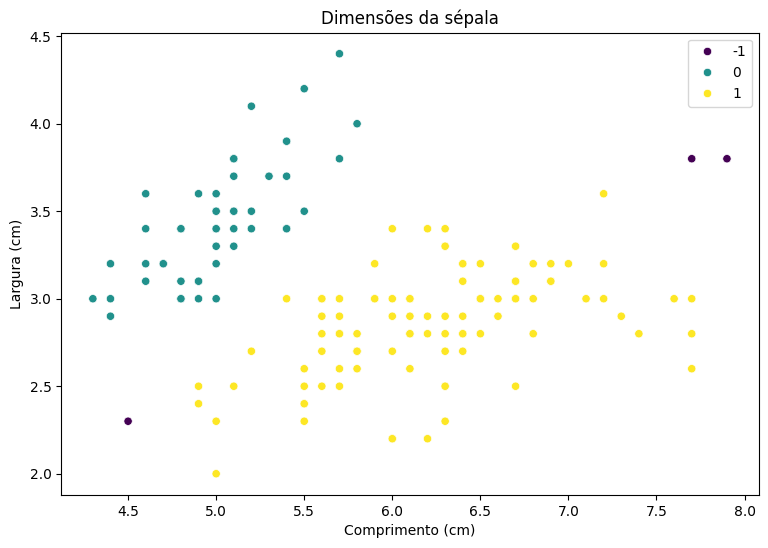

In [25]:
# Diagrama de dispersão entre comprimento e largura da sépala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

### **5.2)** Ajuste automatizado do raio de alcance

In [26]:
# Abordagem matemática: cotovelo = ponto de curvatura máxima!
# Instalação de biblioteca para detecção do joelho/cotovelo
# Descrição do projeto: https://pypi.org/project/kneed/
!pip install kneed

Cotovelo em x = 145
k-distância associada = 1.5667815322562533



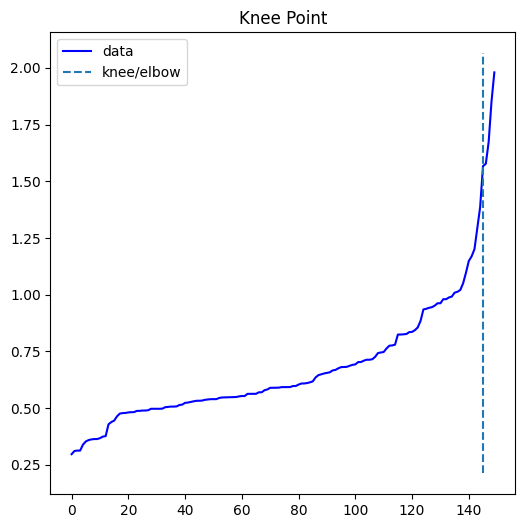

In [27]:
# Importação e aplicação da função de detecção
from kneed import KneeLocator

cotovelo = KneeLocator(x = range(0,len(k_dist)), y = k_dist,
                       S = 1.0, curve = "concave",
                       direction = "increasing",
                       online = True)

print("Cotovelo em x =",cotovelo.elbow)             # Opção: objeto.knee
print("k-distância associada =",cotovelo.elbow_y)   # Opção: objeto.knee_y
print("")   # "Imprime" uma linha em branco

# Exibição gráfica do resultado
cotovelo.plot_knee()
plt.show()

## **6)** Agrupamento final

In [28]:
# Treinamento FINAL do algoritmo DBSCAN com hiperparâmetros dimensionados
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = cotovelo.elbow_y, min_samples = k)
clt_DB.fit(X_Padr)

DBSCAN(eps=np.float64(1.5667815322562533), min_samples=8)

In [29]:
# Exibição dos resultados do NOVO agrupamento
# Total de cluters e outliers
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

print("")   # "Imprime" uma linha em branco
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Rótulos atribuídos: [0 1]
0 elementos foram identificados como ruído.

Total de elementos por cluster:
1    100
0     50
Name: count, dtype: int64


#### **6.1)** Gráficos finais

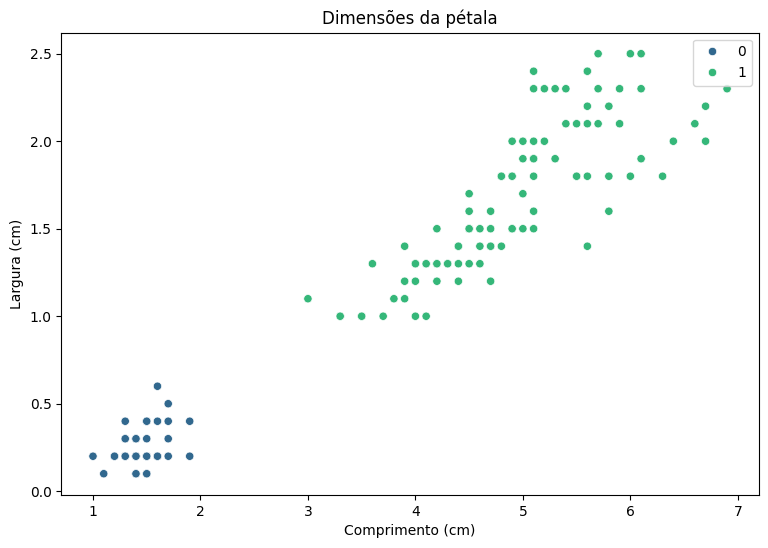

In [30]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

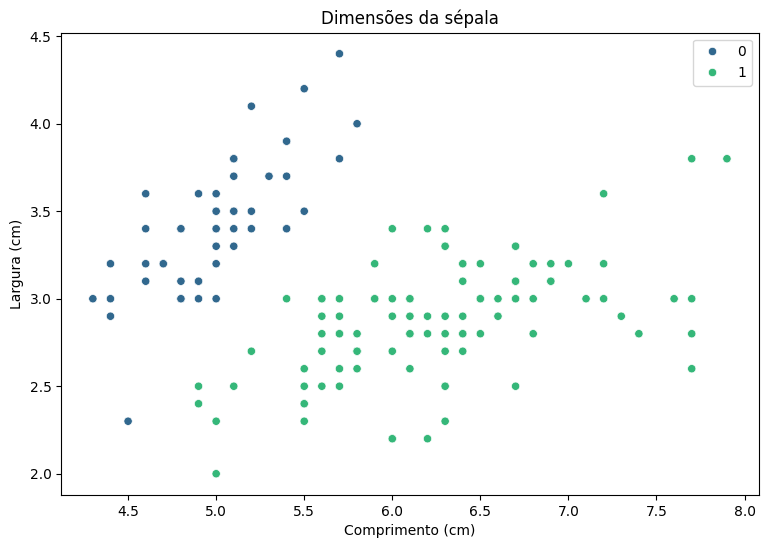

In [31]:
# Diagrama de dispersão entre comprimento e largura da sépala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

---
**Fim do exercício 1 da Aula 08**